
# Bike Demand Prediction
## Problem Statement: To build a simple logistic regression model for prediction of high demand of bikes given the below features.Dependent variable needs to derived using “cnt” variable with definition: cnt >= 200.

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset 
df = pd.read_csv('/Users/aman/Desktop/dsb-case-studies/bike-demand-prediction/data/hour.csv')

In [3]:
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [5]:
df['high_demand'] = (df["cnt"] >= 200).astype(int)
df[["cnt","high_demand"]].head(10)
df["high_demand"].value_counts()

high_demand
0    10763
1     6616
Name: count, dtype: int64

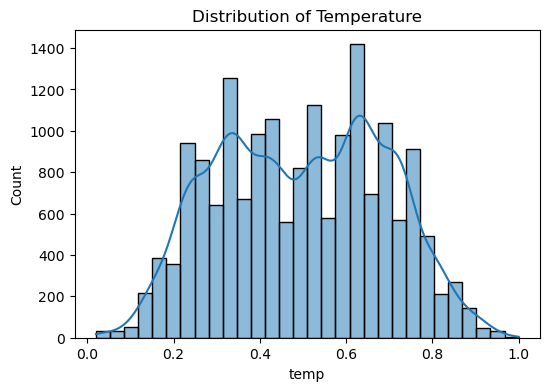

In [6]:
# EDA 
#Univariate Analysis
#For numerical distributions like temperature
plt.figure(figsize = (6,4))
sns.histplot(df["temp"], bins=30, kde=True)
plt.title("Distribution of Temperature")
plt.show()


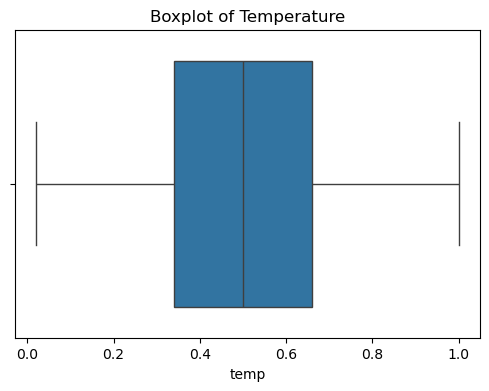

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["temp"])
plt.title("Boxplot of Temperature")
plt.show()

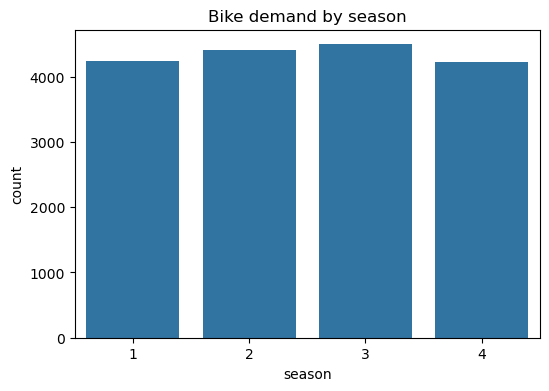

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x = df["season"])
plt.title("Bike demand by season")
plt.show()

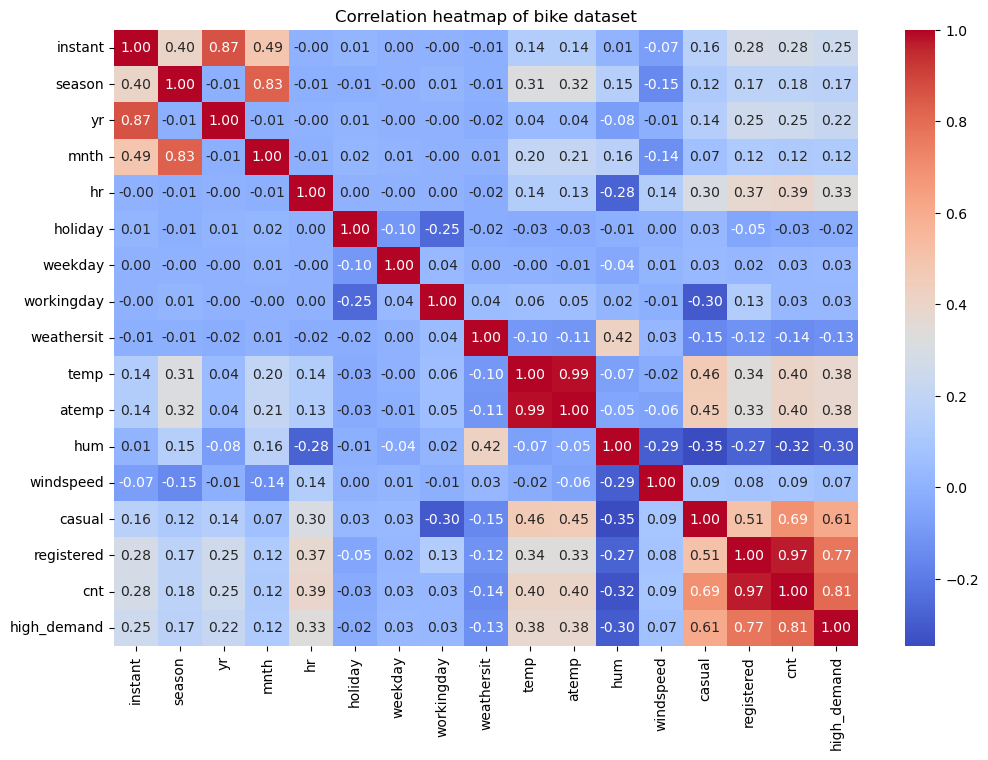

In [9]:
#Coorelation analysis
plt.figure(figsize=(12,8))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix,annot = True, cmap="coolwarm" , fmt=".2f")
plt.title("Correlation heatmap of bike dataset")
plt.show()

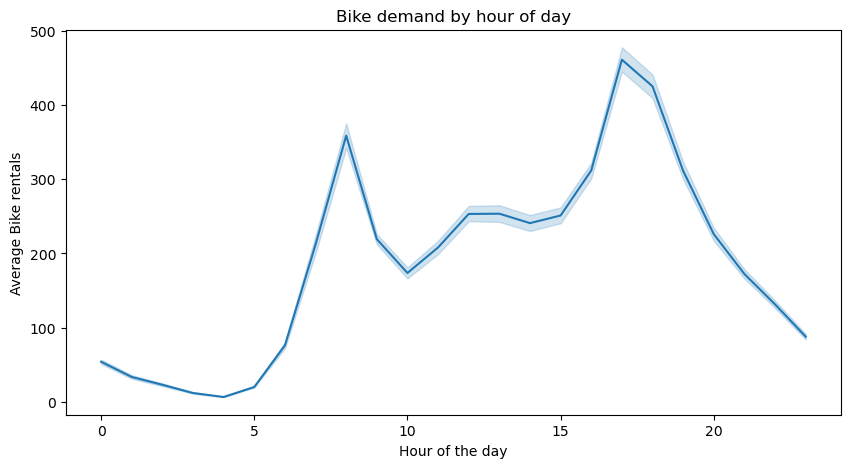

In [10]:
# Bivariate analysis for hour vs cnt
#Categorical vs numerical hence the lineplot
plt.figure(figsize=(10,5))
sns.lineplot(x="hr", y="cnt", data =df)
plt.title("Bike demand by hour of day")
plt.xlabel("Hour of the day")
plt.ylabel("Average Bike rentals")
plt.show()


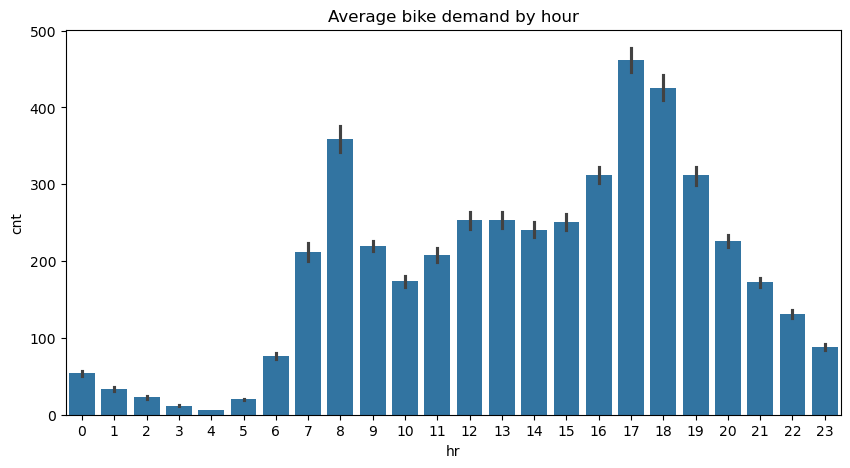

In [11]:
#Alternative bar plot
plt.figure(figsize=(10,5))
sns.barplot(x="hr", y="cnt", data =df)
plt.title("Average bike demand by hour")
plt.show()

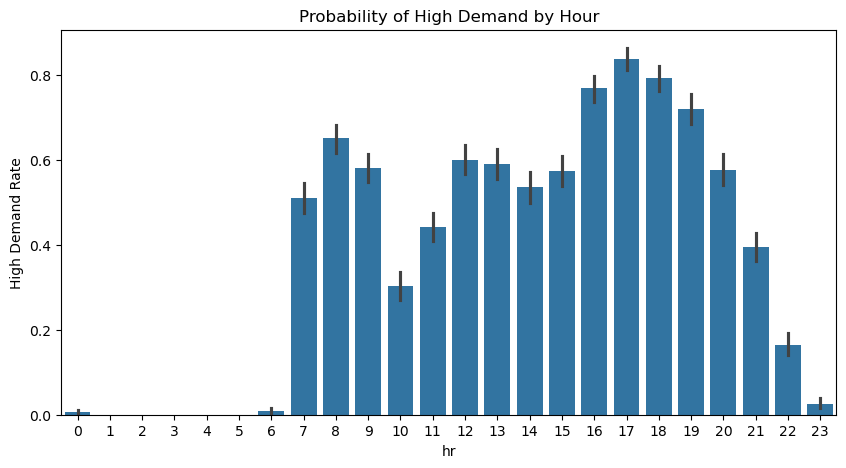

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(x="hr", y="high_demand", data=df)

plt.title("Probability of High Demand by Hour")

plt.ylabel("High Demand Rate")

plt.show()

Bivariate analysis was performed to understand the relationship between hour of the day and bike demand. The results indicate clear temporal patterns, with demand peaking during typical commuting hours in the morning and evening. This suggests that bike usage is strongly influenced by daily work schedules.

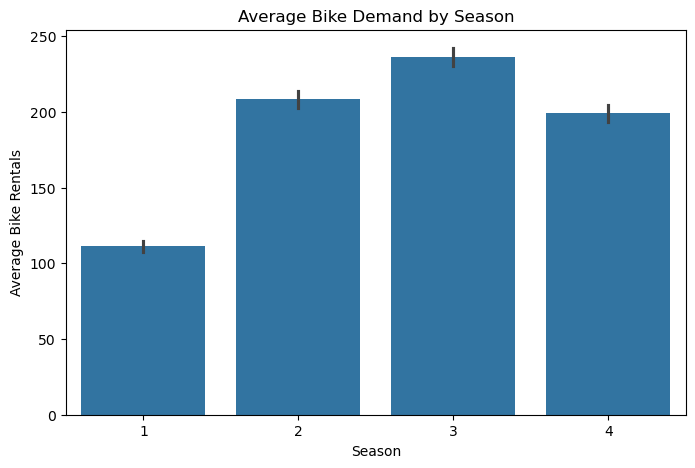

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(x="season", y="cnt", data=df)

plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")

plt.show()

Bivariate analysis was conducted to study the relationship between season and bike demand. A barplot was used to visualize average bike rentals across seasons. The analysis indicates that bike demand tends to be higher in warmer seasons, while colder seasons show lower demand levels. This suggests that weather conditions significantly influence bike usage.

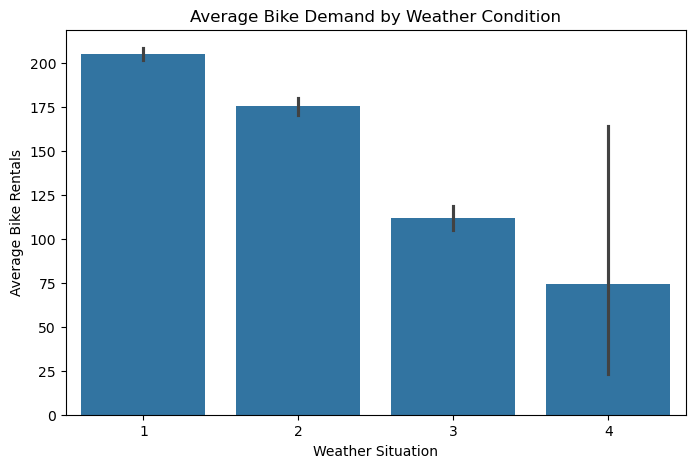

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Average Bike Demand by Weather Condition")
plt.xlabel("Weather Situation")
plt.ylabel("Average Bike Rentals")

plt.show()

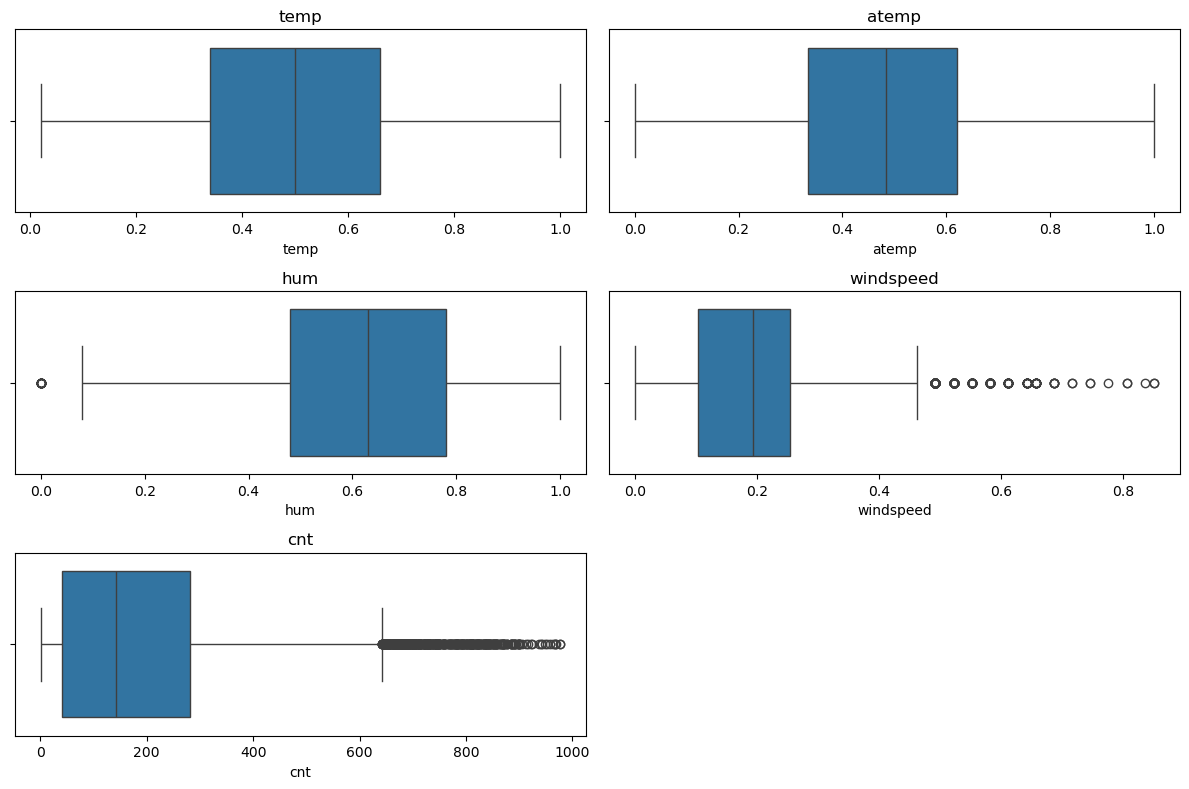

In [15]:
#vISUALIZE OUTLIERS WITH BOXPLOTS in numerical variables
numerical_cols = ["temp","atemp","hum","windspeed","cnt"]
plt.figure(figsize = (12,8))
for i,col in enumerate(numerical_cols,1):
    plt.subplot(3,2,i)
    sns.boxplot(x = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [16]:
#Feature engineering and dropping the unnecessary columns 
df_model = df.drop(columns=["instant","dteday","casual","registered","cnt"])

In [17]:
X = df_model.drop("high_demand", axis =1)
Y = df_model["high_demand"]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)


In [19]:
print(X_train.shape)
print(X_test.shape)

(13903, 12)
(3476, 12)


Before model training, the dataset was divided into feature variables (X) and the target variable (y). Data leakage variables such as casual, registered, and cnt were removed. The dataset was then split into training and testing sets using an 80-20 ratio to ensure proper model evaluation on unseen data.

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)


In [21]:
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(X_test)

In [23]:
y_prob = model.predict_proba(X_test)

In [26]:
print(y_pred[:10])

[1 0 0 1 0 0 1 0 0 0]


[[1882  327]
 [ 443  824]]


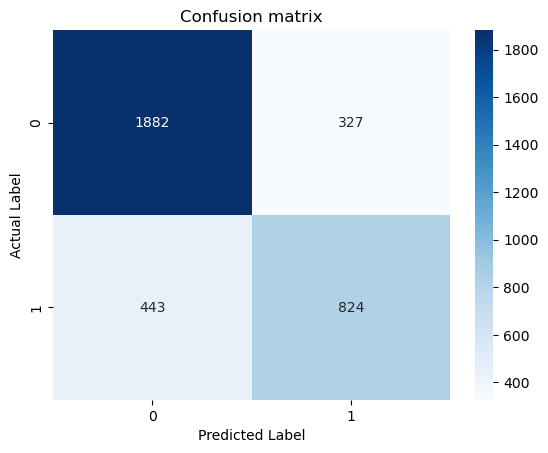

In [27]:
#Model evaluation
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
print(cm)
sns.heatmap(cm , annot=True, fmt='d',cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion matrix")
plt.show()

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
print("Accuracy: ",accuracy)
print("Precision:", precision)
from sklearn.metrics import recall_score
recall = recall_score(Y_test, y_pred)
print("Recall:", recall)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test, y_pred)
print("F1 Score:", f1)

Accuracy:  0.7784810126582279
Precision: 0.7158992180712423
Recall: 0.6503551696921863
F1 Score: 0.6815550041356493


In [34]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      2209
           1       0.72      0.65      0.68      1267

    accuracy                           0.78      3476
   macro avg       0.76      0.75      0.76      3476
weighted avg       0.78      0.78      0.78      3476



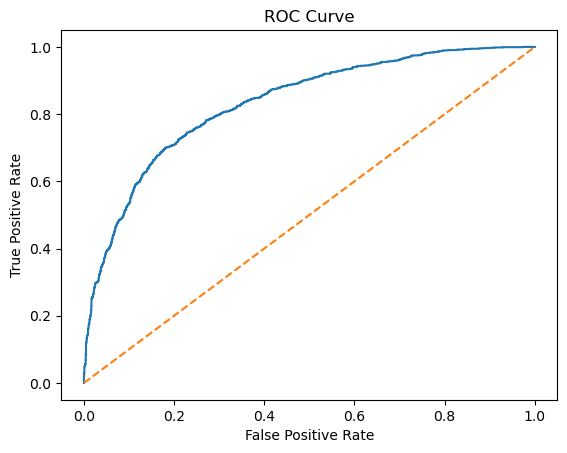

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Y_test, y_prob[:,1])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [36]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(Y_test, y_prob[:,1])
print("AUC:", auc)

AUC: 0.8322414975259066


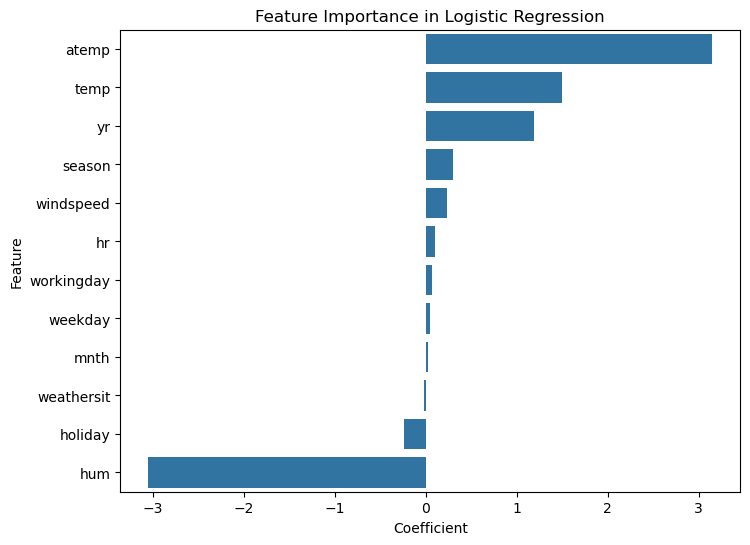

In [37]:
#Extracting model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients
plt.figure(figsize=(8,6))

sns.barplot(x="Coefficient", y="Feature", data=coefficients)

plt.title("Feature Importance in Logistic Regression")

plt.show()

Logistic regression coefficients were analyzed to understand the factors influencing high bike demand. The results show that temperature-related variables (atemp and temp) have the strongest positive impact on demand, indicating that bike usage increases significantly during warmer weather. Humidity has the strongest negative effect, suggesting that uncomfortable weather conditions reduce bike usage. The year variable also shows a positive influence, reflecting the growing popularity of the bike-sharing system over time.